In [ ]:
import os
import shutil

working_dir = "/kaggle/working"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # delete file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # delete directory
    except Exception as e:
        print(f"Failed to delete {file_path}. Reason: {e}")

print("✅ /kaggle/working is now empty")

In [2]:
# ============================================================
# CELL 1 | Environment Setup & Verification (final)
# Kaggle: Python 3.12 | CUDA 12.8 | T4 x2
# ============================================================

import subprocess, sys

def pip_install(packages: str):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet"] + packages.split(),
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"❌ FAILED: {packages}")
        print(result.stderr[-1500:])
    else:
        print(f"✅ {packages.split()[0]}")

# --- Transformers & quantization ---
pip_install("transformers==4.44.2")
pip_install("accelerate==0.34.2")
pip_install("bitsandbytes==0.44.1")
pip_install("sentence-transformers==3.0.1")
pip_install("langchain-huggingface==0.0.3")

# --- LangChain ---
pip_install("langchain==0.2.16")
pip_install("langchain-community==0.2.16")
pip_install("langchain-text-splitters==0.2.4")
pip_install("pypdf==4.2.0")

# --- Vector store ---
pip_install("chromadb==0.4.24")

# --- Speech ---
pip_install("faster-whisper==1.0.3")
pip_install("gTTS==2.5.1")
pip_install("soundfile==0.12.1")
pip_install("sounddevice==0.4.6")

# --- App ---
pip_install("streamlit==1.35.0")

# --- Vision ---
pip_install("Pillow==10.3.0")
pip_install("opencv-python-headless==4.8.1.78")

print("\n--- All installs attempted ---\n")

# ============================================================
# SURGICAL PATCH: fix np.float_ in chromadb's types.py
# This targets the exact broken line regardless of which
# chromadb version Kaggle loads from its system path
# ============================================================
import pathlib, re

chroma_types = pathlib.Path(
    "/usr/local/lib/python3.12/dist-packages/chromadb/api/types.py"
)

if chroma_types.exists():
    original = chroma_types.read_text()
    patched  = original.replace(
        "ImageDType = Union[np.uint, np.int_, np.float_]",
        "ImageDType = Union[np.unsignedinteger, np.signedinteger, np.floating]"
    )
    if patched != original:
        chroma_types.write_text(patched)
        print("🩹 chromadb types.py patched for NumPy 2.0 compatibility")
    else:
        print("✅ chromadb types.py already clean")
else:
    print("⚠️  chromadb types.py not found at expected path")

# ============================================================
# Verification
# ============================================================
import torch
import transformers
import langchain
import chromadb
import streamlit
from faster_whisper import WhisperModel

print("📦 Library Versions:")
print(f"  torch              : {torch.__version__}")
print(f"  transformers       : {transformers.__version__}")
print(f"  langchain          : {langchain.__version__}")
print(f"  chromadb           : {chromadb.__version__}")
print(f"  streamlit          : {streamlit.__version__}")

print("\n🖥️  Hardware:")
print(f"  CUDA available     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU count          : {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}              : {torch.cuda.get_device_name(i)}")
    print(f"  CUDA version       : {torch.version.cuda}")
else:
    print("  ⚠️  No GPU — check Kaggle accelerator settings")

✅ transformers==4.44.2
✅ accelerate==0.34.2
✅ bitsandbytes==0.44.1
✅ sentence-transformers==3.0.1
✅ langchain-huggingface==0.0.3
✅ langchain==0.2.16
✅ langchain-community==0.2.16
✅ langchain-text-splitters==0.2.4
✅ pypdf==4.2.0
✅ chromadb==0.4.24
✅ faster-whisper==1.0.3
✅ gTTS==2.5.1
✅ soundfile==0.12.1
✅ sounddevice==0.4.6
✅ streamlit==1.35.0
✅ Pillow==10.3.0
✅ opencv-python-headless==4.8.1.78

--- All installs attempted ---

🩹 chromadb types.py patched for NumPy 2.0 compatibility
📦 Library Versions:
  torch              : 2.10.0+cu128
  transformers       : 4.44.2
  langchain          : 0.2.16
  chromadb           : 0.4.24
  streamlit          : 1.35.0

🖥️  Hardware:
  CUDA available     : True
  GPU count          : 2
  GPU 0              : Tesla T4
  GPU 1              : Tesla T4
  CUDA version       : 12.8


📂 File Discovery:
  PDFs found : 1 → ['/kaggle/input/datasets/ahmedrusrus/pdffortest/Wildlife-AnIntroduction.pdf']
  CSVs found : 0 → none
  Strategy   : local files

📥 Loading Documents:


/usr/local/lib/python3.12/dist-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from this module in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


  ✅ PDF loaded  : Wildlife-AnIntroduction.pdf (31 pages)

  Total raw documents loaded: 31

🧹 Cleaning:
  Before : 31 docs
  After  : 30 docs (dropped 1 near-empty)

✂️  Chunking:
  Total chunks : 30
  Chunk size   : 900 chars | overlap: 120
  Min length   : 65 | Max: 781 | Mean: 369

🔢 Building embeddings with: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
2026-04-28 14:10:13.500016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777385413.736905     239 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777385413.806369     239 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777385414.344058     239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the sam

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
/tmp/ipykernel_239/921129465.py:207: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


  ✅ Vectorstore built & persisted → /tmp/chroma_db
  Indexed 30 chunks

🔍 Retrieval check — query: 'What is retrieval augmented generation?'

  [1] Score: 1.5798 | Source: pdf:Wildlife-AnIntroduction.pdf
       •Itisapriceless value which may bepopular and widespread innature and may beimportant forgenerating awareness inpublic m...

  [2] Score: 1.6828 | Source: pdf:Wildlife-AnIntroduction.pdf
       Aesthetic & Recreational values •Value which pertain toinborn natural beauty and artistic appreciations are grouped unde...

  [3] Score: 1.7368 | Source: pdf:Wildlife-AnIntroduction.pdf
       Animal classes based ontheir dependency onhuman forsurvival : •Free living animals :Animals that isnot directly dependen...


/tmp/ipykernel_239/921129465.py:276: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239/921129465.py:277: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("pipeline_analysis.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


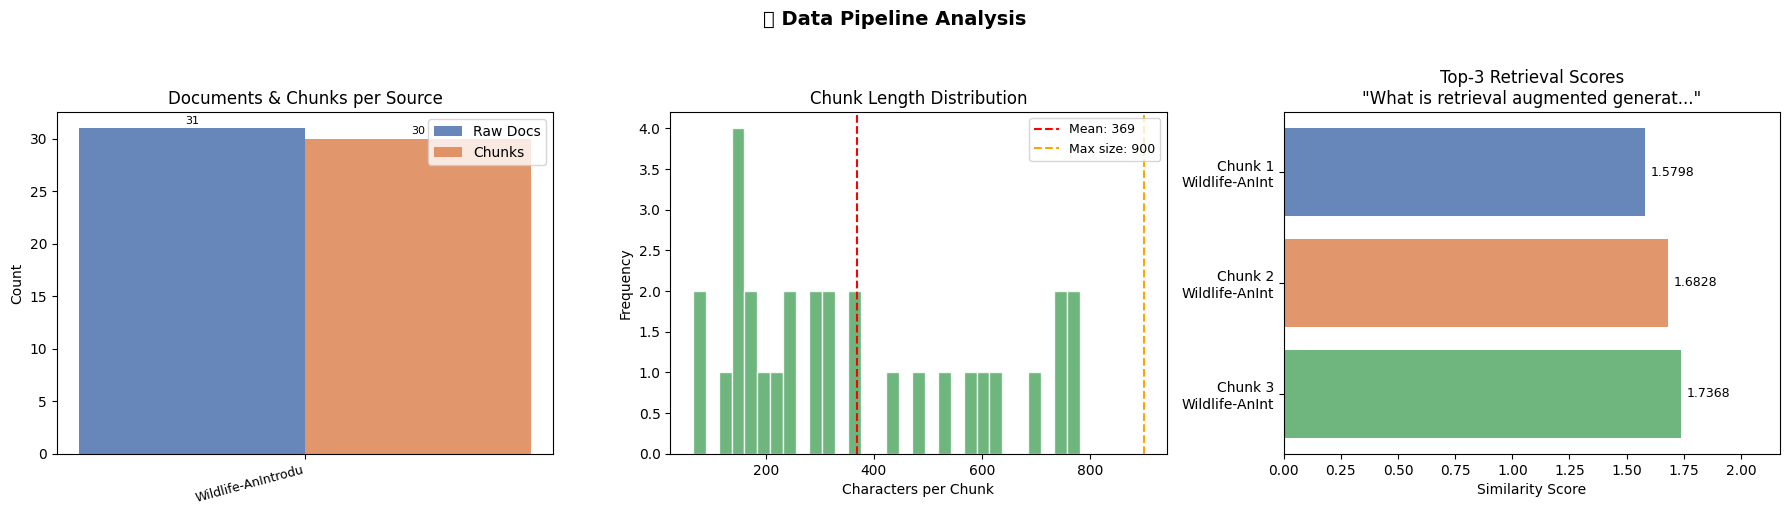


✅ Cell 2 complete — vectorstore ready, plots saved.


In [1]:
# ============================================================
# CELL 2 | Data Ingestion, Cleaning, Chunking & Indexing
# Sources: PDF / CSV (if uploaded) → fallback to arXiv
# Outputs: Chroma vectorstore + 3 analysis plots
# ============================================================

# --- 0. Imports ---
import os, re, shutil
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from langchain_community.document_loaders import PyPDFLoader, CSVLoader, ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.schema import Document

# ============================================================
# 1. CONSTANTS — change only here, never scattered in code
# ============================================================
CHUNK_SIZE        = 900
CHUNK_OVERLAP     = 120
RETRIEVAL_K       = 3
EMBED_MODEL       = "sentence-transformers/all-MiniLM-L6-v2"
CHROMA_DIR        = "/tmp/chroma_db"
ARXIV_FALLBACK_ID = "2201.11095"   # RAG survey paper — always available
SAMPLE_QUERY      = "What is retrieval augmented generation?"

# Kaggle upload paths — script checks these automatically
UPLOAD_DIR        = Path("/kaggle/input/datasets/ahmedrusrus/pdffortest")
PDF_PATTERN       = "*.pdf"
CSV_PATTERN       = "*.csv"

# ============================================================
# 2. SMART FILE DISCOVERY
# Scans /kaggle/input recursively for PDFs and CSVs.
# If nothing is found, falls back to arXiv gracefully.
# ============================================================
def discover_files(upload_dir: Path) -> Dict[str, List[Path]]:
    """Recursively find all PDF and CSV files in Kaggle input directory."""
    found = {
        "pdf": list(upload_dir.rglob(PDF_PATTERN)),
        "csv": list(upload_dir.rglob(CSV_PATTERN)),
    }
    return found

discovered = discover_files(UPLOAD_DIR)
has_pdf    = len(discovered["pdf"]) > 0
has_csv    = len(discovered["csv"]) > 0
use_arxiv  = not has_pdf and not has_csv

print("📂 File Discovery:")
print(f"  PDFs found : {len(discovered['pdf'])} → {[str(p) for p in discovered['pdf']] or 'none'}")
print(f"  CSVs found : {len(discovered['csv'])} → {[str(p) for p in discovered['csv']] or 'none'}")
print(f"  Strategy   : {'arXiv fallback (no local files detected)' if use_arxiv else 'local files'}")

# ============================================================
# 3. DOCUMENT LOADERS
# ============================================================
def load_pdf(path: Path) -> List[Document]:
    try:
        docs = PyPDFLoader(str(path)).load()
        print(f"  ✅ PDF loaded  : {path.name} ({len(docs)} pages)")
        return docs
    except Exception as e:
        print(f"  ❌ PDF failed  : {path.name} — {e}")
        return []

def load_csv(path: Path) -> List[Document]:
    try:
        docs = CSVLoader(str(path)).load()
        print(f"  ✅ CSV loaded  : {path.name} ({len(docs)} rows)")
        return docs
    except Exception as e:
        print(f"  ❌ CSV failed  : {path.name} — {e}")
        return []

def load_arxiv(arxiv_id: str) -> List[Document]:
    try:
        docs = ArxivLoader(query=arxiv_id, load_max_docs=1).load()
        print(f"  ✅ arXiv loaded: {arxiv_id} ({len(docs)} doc)")
        return docs
    except Exception as e:
        print(f"  ❌ arXiv failed: {arxiv_id} — {e}")
        return []

def normalize_docs(docs: List[Document], source_tag: str) -> List[Document]:
    """Standardize metadata schema across all source types."""
    normalized = []
    for i, doc in enumerate(docs):
        normalized.append(Document(
            page_content=doc.page_content,
            metadata={
                "source"    : source_tag,
                "doc_index" : i,
                "origin"    : doc.metadata.get("source", source_tag),
            }
        ))
    return normalized

# --- Load all available sources ---
print("\n📥 Loading Documents:")
raw_docs: List[Document] = []
source_counts: Dict[str, int] = {}

if has_pdf:
    for pdf_path in discovered["pdf"]:
        docs = load_pdf(pdf_path)
        norm = normalize_docs(docs, f"pdf:{pdf_path.name}")
        raw_docs.extend(norm)
        source_counts[f"pdf:{pdf_path.name}"] = len(norm)

if has_csv:
    for csv_path in discovered["csv"]:
        docs = load_csv(csv_path)
        norm = normalize_docs(docs, f"csv:{csv_path.name}")
        raw_docs.extend(norm)
        source_counts[f"csv:{csv_path.name}"] = len(norm)

if use_arxiv:
    docs = load_arxiv(ARXIV_FALLBACK_ID)
    norm = normalize_docs(docs, f"arxiv:{ARXIV_FALLBACK_ID}")
    raw_docs.extend(norm)
    source_counts[f"arxiv:{ARXIV_FALLBACK_ID}"] = len(norm)

print(f"\n  Total raw documents loaded: {len(raw_docs)}")

# ============================================================
# 4. CLEANING
# ============================================================
def clean_text(text: str) -> str:
    """Deterministic text normalization pipeline."""
    text = re.sub(r'-\n',        '',    text)   # fix hyphenated line breaks
    text = re.sub(r'(?<!\n)\n(?!\n)', ' ', text) # single newline → space
    text = re.sub(r'\n{3,}',    '\n\n', text)   # 3+ newlines → paragraph break
    text = re.sub(r'[ \t]+',    ' ',    text)   # collapse spaces/tabs
    return text.strip()

def clean_documents(docs: List[Document]) -> List[Document]:
    return [
        Document(page_content=clean_text(doc.page_content), metadata=doc.metadata)
        for doc in docs
        if len(doc.page_content.strip()) > 30   # drop near-empty pages
    ]

cleaned_docs = clean_documents(raw_docs)
print(f"\n🧹 Cleaning:")
print(f"  Before : {len(raw_docs)} docs")
print(f"  After  : {len(cleaned_docs)} docs (dropped {len(raw_docs)-len(cleaned_docs)} near-empty)")

# ============================================================
# 5. CHUNKING
# ============================================================
def chunk_documents(docs: List[Document]) -> List[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    chunks = []
    for doc_i, doc in enumerate(docs):
        splits = splitter.split_text(doc.page_content)
        for chunk_i, text in enumerate(splits):
            chunks.append(Document(
                page_content=text,
                metadata={**doc.metadata, "chunk_index": chunk_i, "doc_index": doc_i}
            ))
    return chunks

chunks = chunk_documents(cleaned_docs)
chunk_lengths = [len(c.page_content) for c in chunks]

# Build per-source chunk counts for plotting
chunk_source_counts: Dict[str, int] = {}
for c in chunks:
    src = c.metadata.get("source", "unknown")
    chunk_source_counts[src] = chunk_source_counts.get(src, 0) + 1

print(f"\n✂️  Chunking:")
print(f"  Total chunks : {len(chunks)}")
print(f"  Chunk size   : {CHUNK_SIZE} chars | overlap: {CHUNK_OVERLAP}")
print(f"  Min length   : {min(chunk_lengths)} | Max: {max(chunk_lengths)} | Mean: {np.mean(chunk_lengths):.0f}")

# ============================================================
# 6. EMBEDDINGS + CHROMA VECTORSTORE
# ============================================================
print(f"\n🔢 Building embeddings with: {EMBED_MODEL}")

if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)
    print(f"  Removed existing Chroma DB at {CHROMA_DIR}")

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    encode_kwargs={"normalize_embeddings": True}
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=CHROMA_DIR
)
vectorstore.persist()
print(f"  ✅ Vectorstore built & persisted → {CHROMA_DIR}")
print(f"  Indexed {len(chunks)} chunks")

# ============================================================
# 7. RETRIEVAL SANITY CHECK
# ============================================================
print(f"\n🔍 Retrieval check — query: '{SAMPLE_QUERY}'")
retriever = vectorstore.as_retriever(search_type="similarity_score_threshold",
                                     search_kwargs={"k": RETRIEVAL_K, "score_threshold": 0.0})

# Get docs + scores separately for plotting
results_with_scores = vectorstore.similarity_search_with_score(SAMPLE_QUERY, k=RETRIEVAL_K)
retrieved_docs       = [r[0] for r in results_with_scores]
retrieval_scores     = [float(r[1]) for r in results_with_scores]

for i, (doc, score) in enumerate(results_with_scores):
    print(f"\n  [{i+1}] Score: {score:.4f} | Source: {doc.metadata.get('source','?')}")
    print(f"       {doc.page_content[:120].strip()}...")

# ============================================================
# 8. ANALYSIS PLOTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📊 Data Pipeline Analysis", fontsize=14, fontweight="bold", y=1.02)

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

# --- Plot 1: Documents & Chunks per Source ---
ax1 = axes[0]
sources      = list(source_counts.keys())
doc_vals     = [source_counts[s] for s in sources]
chunk_vals   = [chunk_source_counts.get(s, 0) for s in sources]
short_labels = [s.split(":")[-1][:18] for s in sources]   # trim long names
x = np.arange(len(sources))
w = 0.35

bars1 = ax1.bar(x - w/2, doc_vals,   w, label="Raw Docs",  color=COLORS[0], alpha=0.85)
bars2 = ax1.bar(x + w/2, chunk_vals, w, label="Chunks",    color=COLORS[1], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, rotation=15, ha="right", fontsize=9)
ax1.set_title("Documents & Chunks per Source")
ax1.set_ylabel("Count")
ax1.legend()
ax1.bar_label(bars1, padding=2, fontsize=8)
ax1.bar_label(bars2, padding=2, fontsize=8)

# --- Plot 2: Chunk Length Distribution ---
ax2 = axes[1]
ax2.hist(chunk_lengths, bins=30, color=COLORS[2], edgecolor="white", alpha=0.85)
ax2.axvline(np.mean(chunk_lengths), color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {np.mean(chunk_lengths):.0f}")
ax2.axvline(CHUNK_SIZE,             color="orange", linestyle="--", linewidth=1.5, label=f"Max size: {CHUNK_SIZE}")
ax2.set_title("Chunk Length Distribution")
ax2.set_xlabel("Characters per Chunk")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=9)

# --- Plot 3: Retrieval Similarity Scores ---
ax3 = axes[2]
labels = [f"Chunk {i+1}\n{retrieved_docs[i].metadata.get('source','?').split(':')[-1][:14]}"
          for i in range(len(retrieval_scores))]
bar_colors = COLORS[:len(retrieval_scores)]
bars3 = ax3.barh(labels, retrieval_scores, color=bar_colors, alpha=0.85)
ax3.set_xlim(0, max(retrieval_scores) * 1.25)
ax3.set_title(f"Top-{RETRIEVAL_K} Retrieval Scores\n\"{SAMPLE_QUERY[:35]}...\"")
ax3.set_xlabel("Similarity Score")
ax3.bar_label(bars3, fmt="%.4f", padding=4, fontsize=9)
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig("pipeline_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Cell 2 complete — vectorstore ready, plots saved.")

CUDA available : True
GPU count      : 2
GPU 0          : Tesla T4
GPU 1          : Tesla T4

⏳ Loading tokenizer ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Model loaded

  GPU 0: 7.34 GB used / 15.64 GB total
  GPU 1: 7.24 GB used / 15.64 GB total

✅ Generation pipeline ready

🦁 SINGLE-TURN RAG DEMO

❓ QUERY: What types of wildlife habitats are described in the document?
💬 ANSWER:
The document describes wildlife as living in two types of habitats: the wild and the domestic. Wild animals live in their natural habitats, which are not influenced or controlled by humans. Domestic animals, on the other hand, live in habitats that have been created or modified by humans for their benefit.

📚 SOURCES USED:
  [1] score=0.8432 | pdf:Wildlife-AnIntroduction.pdf
       Conclusion •Wildlife is an important renewable natural resource at the hard of man with diverse use....
  [2] score=0.8519 | pdf:Wildlife-AnIntroduction.pdf
       Ecological values •Wild animals are asmuch apart ofnature asman and have a significant role toplay i...
  [3] score=0.9673 | pdf:Wildlife-AnIntroduction.pdf
       WILDLIFE •Atpresent, life onearth includes human beings a

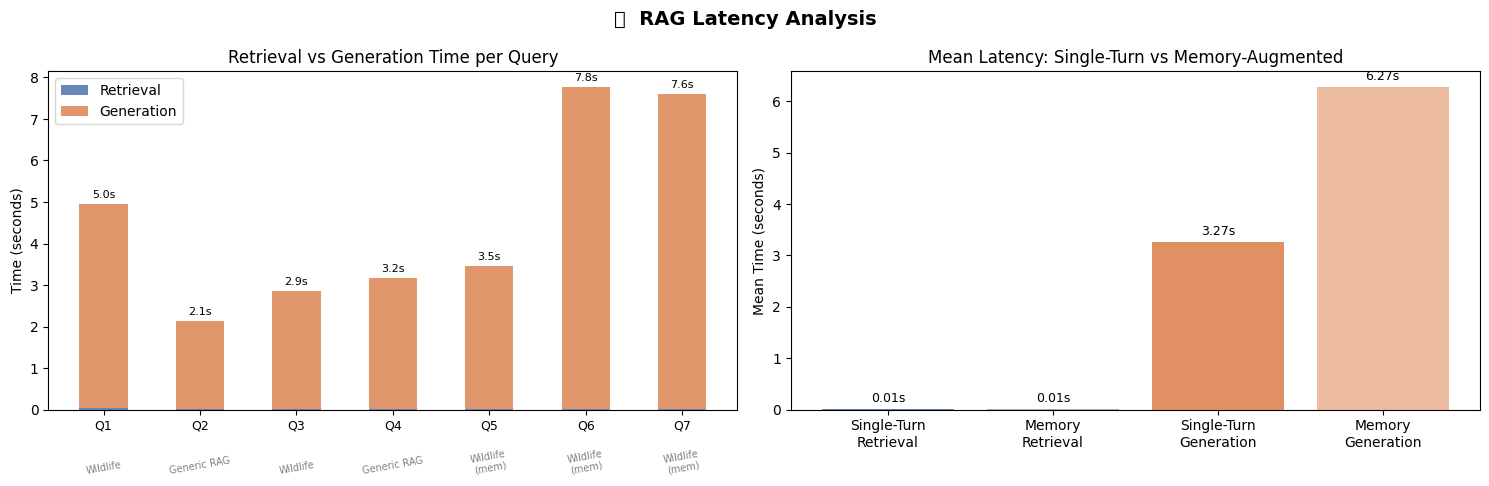


✅ Cell 3 complete — RAG core ready, latency plot saved.


In [2]:
# ============================================================
# CELL 3 | RAG Core — LLM + Text QA + Conversation Memory
# Model : mistralai/Mistral-7B-Instruct-v0.2
# Quant : float16 directly on GPU (no bitsandbytes needed)
# Device: auto across both T4s (32GB total VRAM)
# ============================================================

import os, time, torch, warnings
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings("ignore")

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from collections import deque
from typing import List, Dict

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU count      : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}          : {torch.cuda.get_device_name(i)}")

# ============================================================
# 1. LOAD MISTRAL-7B IN FLOAT16 — no bitsandbytes required
# device_map="auto" splits layers across both T4s via accelerate
# ============================================================
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

print(f"\n⏳ Loading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print(f"⏳ Loading model in float16 — ~2 min on T4 x2 ...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print("✅ Model loaded\n")

for i in range(torch.cuda.device_count()):
    alloc = torch.cuda.memory_allocated(i) / 1e9
    total = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {alloc:.2f} GB used / {total:.2f} GB total")

# ============================================================
# 2. GENERATION PIPELINE
# ============================================================
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=False,
    temperature=1.0,
    repetition_penalty=1.05,
    return_full_text=False,
)
print("\n✅ Generation pipeline ready")

# ============================================================
# 3. PROMPT BUILDER — Mistral [INST] format
# ============================================================
def build_prompt(query: str, context_docs: List) -> str:
    context_text = "\n\n".join(
        f"[Source {i+1} | {doc.metadata.get('source', 'unknown')}]\n{doc.page_content.strip()}"
        for i, doc in enumerate(context_docs)
    )
    return (
        "[INST] You are a helpful assistant. Answer the question using ONLY "
        "the context provided below. If the answer is not in the context, "
        "say 'I don't have enough information to answer that.'\n\n"
        f"CONTEXT:\n{context_text}\n\n"
        f"QUESTION: {query} [/INST]"
    )

# ============================================================
# 4. SINGLE-TURN RAG
# ============================================================
def rag_answer(query: str, k: int = RETRIEVAL_K) -> Dict:
    t0 = time.time()
    results = vectorstore.similarity_search_with_score(query, k=k)
    retrieval_time = time.time() - t0
    docs   = [r[0] for r in results]
    scores = [r[1] for r in results]

    prompt = build_prompt(query, docs)
    t1 = time.time()
    output = llm_pipeline(prompt)[0]["generated_text"].strip()
    generation_time = time.time() - t1

    return {
        "query"          : query,
        "answer"         : output,
        "sources"        : docs,
        "scores"         : scores,
        "retrieval_time" : retrieval_time,
        "generation_time": generation_time,
    }

def print_rag_result(result: Dict):
    print(f"\n{'='*60}")
    print(f"❓ QUERY: {result['query']}")
    print(f"{'='*60}")
    print(f"💬 ANSWER:\n{result['answer']}")
    print(f"\n📚 SOURCES USED:")
    for i, (doc, score) in enumerate(zip(result["sources"], result["scores"])):
        print(f"  [{i+1}] score={score:.4f} | {doc.metadata.get('source','?')}")
        print(f"       {doc.page_content[:100].strip()}...")
    print(f"\n⏱️  Retrieval: {result['retrieval_time']:.2f}s | Generation: {result['generation_time']:.2f}s")

# ============================================================
# 5. CONVERSATION MEMORY
# ============================================================
class ConversationMemory:
    """Rolling window memory — keeps last max_turns exchanges."""
    def __init__(self, max_turns: int = 6):
        self.max_turns = max_turns
        self.history: deque = deque(maxlen=max_turns)

    def add(self, role: str, content: str):
        self.history.append({"role": role, "content": content})

    def get_context_string(self) -> str:
        if not self.history:
            return ""
        return "\n".join(
            f"{'User' if t['role']=='user' else 'Assistant'}: {t['content']}"
            for t in self.history
        )

    def clear(self):
        self.history.clear()

    def __len__(self):
        return len(self.history)

# ============================================================
# 6. MEMORY-AWARE RAG
# ============================================================
def build_prompt_with_memory(query: str, context_docs: List, memory: ConversationMemory) -> str:
    context_text = "\n\n".join(
        f"[Source {i+1} | {doc.metadata.get('source', 'unknown')}]\n{doc.page_content.strip()}"
        for i, doc in enumerate(context_docs)
    )
    history_text    = memory.get_context_string()
    history_section = f"\nCONVERSATION HISTORY:\n{history_text}\n" if history_text else ""
    return (
        "[INST] You are a helpful assistant. Answer using ONLY the context "
        "provided. Use the conversation history for follow-up references. "
        "If the answer is not in the context, say 'I don't have enough information.'\n\n"
        f"CONTEXT:\n{context_text}"
        f"{history_section}\n"
        f"QUESTION: {query} [/INST]"
    )

def rag_answer_with_memory(query: str, memory: ConversationMemory, k: int = RETRIEVAL_K) -> Dict:
    t0 = time.time()
    results = vectorstore.similarity_search_with_score(query, k=k)
    retrieval_time = time.time() - t0
    docs   = [r[0] for r in results]
    scores = [r[1] for r in results]

    prompt = build_prompt_with_memory(query, docs, memory)
    t1 = time.time()
    output = llm_pipeline(prompt)[0]["generated_text"].strip()
    generation_time = time.time() - t1

    memory.add("user",      query)
    memory.add("assistant", output)

    return {
        "query"          : query,
        "answer"         : output,
        "sources"        : docs,
        "scores"         : scores,
        "retrieval_time" : retrieval_time,
        "generation_time": generation_time,
    }

# ============================================================
# 7. DEMO RUNS
# ============================================================
DEMO_QUESTIONS = [
    "What types of wildlife habitats are described in the document?",
    "What is retrieval augmented generation and how does it work?",
    "How do animals adapt to their environment according to the text?",
    "What are the main challenges in building a QA system?",
]

print("\n" + "="*60)
print("🦁 SINGLE-TURN RAG DEMO")
print("="*60)
single_turn_results = []
for q in DEMO_QUESTIONS:
    result = rag_answer(q)
    print_rag_result(result)
    single_turn_results.append(result)

print("\n" + "="*60)
print("🧠 MULTI-TURN MEMORY RAG DEMO")
print("="*60)
memory = ConversationMemory(max_turns=6)
memory_questions = [
    "What wildlife species are mentioned in the document?",
    "Can you tell me more about their feeding habits?",
    "How does this relate to ecosystem balance?",
]
memory_results = []
for q in memory_questions:
    print(f"\n[Memory turns stored: {len(memory)}]")
    result = rag_answer_with_memory(q, memory)
    print_rag_result(result)
    memory_results.append(result)

# ============================================================
# 8. ANALYSIS PLOT — Latency Breakdown
# ============================================================
all_results = single_turn_results + memory_results
labels      = [f"Q{i+1}" for i in range(len(all_results))]
ret_times   = [r["retrieval_time"]  for r in all_results]
gen_times   = [r["generation_time"] for r in all_results]
q_types     = (
    ["Wildlife", "Generic RAG", "Wildlife", "Generic RAG"]
  + ["Wildlife\n(mem)", "Wildlife\n(mem)", "Wildlife\n(mem)"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("⏱️  RAG Latency Analysis", fontsize=14, fontweight="bold")

# Plot 1: stacked bar per question
ax1 = axes[0]
x   = np.arange(len(labels))
w   = 0.5
b1  = ax1.bar(x, ret_times, w, label="Retrieval",  color="#4C72B0", alpha=0.85)
b2  = ax1.bar(x, gen_times, w, label="Generation", color="#DD8452",
              bottom=ret_times, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Time (seconds)")
ax1.set_title("Retrieval vs Generation Time per Query")
ax1.legend()
totals = [r+g for r,g in zip(ret_times, gen_times)]
ax1.bar_label(b2, labels=[f"{t:.1f}s" for t in totals], padding=3, fontsize=8)
for i, qt in enumerate(q_types):
    ax1.text(i, -max(gen_times)*0.2, qt, ha="center", fontsize=7, color="gray", rotation=10)

# Plot 2: mean latency single-turn vs memory
ax2         = axes[1]
st_ret_mean = np.mean([r["retrieval_time"]  for r in single_turn_results])
mt_ret_mean = np.mean([r["retrieval_time"]  for r in memory_results])
st_gen_mean = np.mean([r["generation_time"] for r in single_turn_results])
mt_gen_mean = np.mean([r["generation_time"] for r in memory_results])

categories = ["Single-Turn\nRetrieval", "Memory\nRetrieval",
              "Single-Turn\nGeneration", "Memory\nGeneration"]
means      = [st_ret_mean, mt_ret_mean, st_gen_mean, mt_gen_mean]
colors     = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"]
alphas     = [0.9, 0.55, 0.9, 0.55]
bars = [ax2.bar(cat, mean, color=col, alpha=alp)
        for cat, mean, col, alp in zip(categories, means, colors, alphas)]
ax2.set_ylabel("Mean Time (seconds)")
ax2.set_title("Mean Latency: Single-Turn vs Memory-Augmented")
for bar, mean in zip(bars, means):
    ax2.bar_label(bar, labels=[f"{mean:.2f}s"], padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("rag_latency_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Cell 3 complete — RAG core ready, latency plot saved.")

📥 Preparing assets ...
  ✅ Wildlife image : /kaggle/input/datasets/ahmedrusrus/bbbbbbb/sample_wildlife.jpg
  ✅ Sample audio downloaded → /tmp/sample_audio.mp3

⏳ Loading BLIP captioning model ...
✅ BLIP captioning ready

🖼️  Generating image caption ...
  Caption : a gife and a gife are standing in the grass
  Time    : 0.26s

⏳ Loading BLIP VQA model ...
✅ BLIP VQA ready

🔍 Running Visual QA ...
  Q: What animal is in the image?
  A: zebra and giraffe  (0.15s)

  Q: What color is the animal?
  A: black and white  (0.11s)

  Q: Is the animal in the wild or indoors?
  A: wild  (0.07s)

⏳ Loading Faster-Whisper STT (base) ...
✅ Whisper STT ready

🎙️  Transcribing sample audio ...
  Language   : en
  Transcript : Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Music Mu
  Time       : 4.18s

🔊 Running Text-to-Speech ...
  Saved to   : /tmp/tts_resp

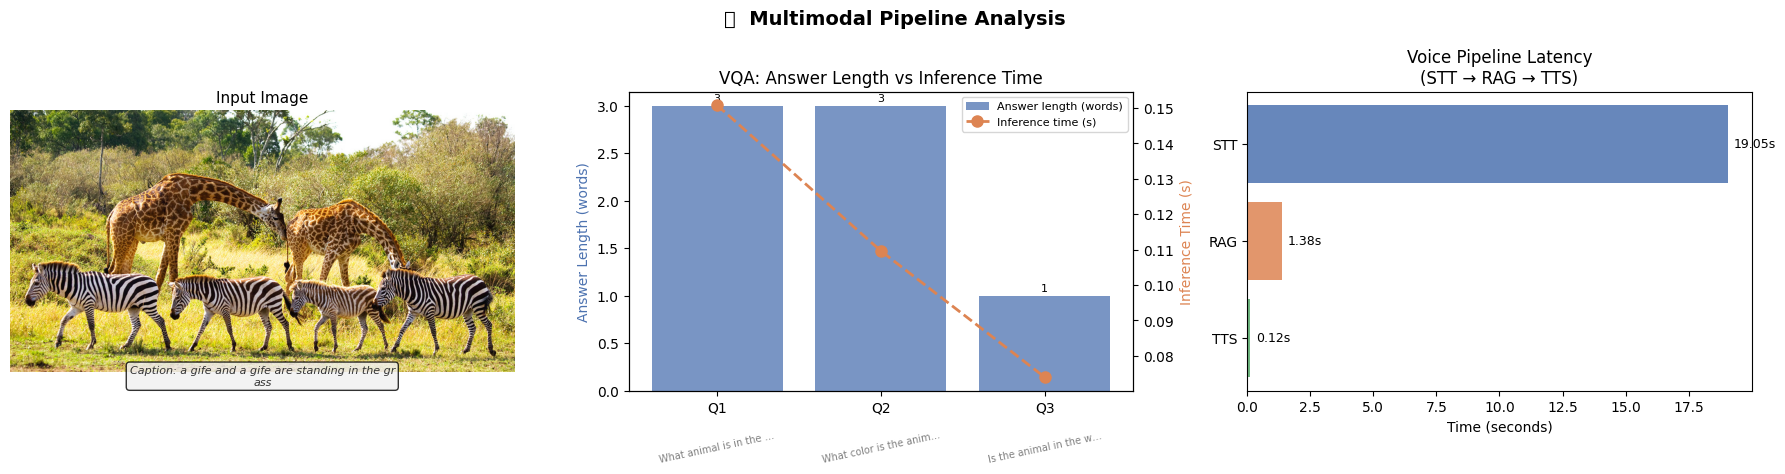


✅ Cell 4 complete — multimodal pipeline ready, plots saved.


In [7]:
# ============================================================
# CELL 4 | Multimodal Extensions — Image + Audio
# BLIP captioning, BLIP VQA, Faster-Whisper STT, gTTS TTS
# All inputs auto-downloaded — no local files required
# ============================================================

import time, os, warnings, requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
import torch
warnings.filterwarnings("ignore")

from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    BlipForQuestionAnswering,
)
from faster_whisper import WhisperModel
from gtts import gTTS

# ============================================================
# 0. ASSET SETUP
# ============================================================
def download_file(url: str, dest: Path, label: str) -> bool:
    """Download a file from a public URL. Returns True on success."""
    try:
        resp = requests.get(url, timeout=30, stream=True)
        resp.raise_for_status()
        dest.write_bytes(resp.content)
        print(f"  ✅ {label} downloaded → {dest}")
        return True
    except Exception as e:
        print(f"  ❌ {label} download failed: {e}")
        return False

IMAGE_PATH = Path("/kaggle/input/datasets/ahmedrusrus/bbbbbbb/sample_wildlife.jpg")
AUDIO_URL  = "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3"
AUDIO_PATH = Path("/tmp/sample_audio.mp3")
TTS_OUT    = Path("/tmp/tts_response.mp3")

print("📥 Preparing assets ...")
img_ok   = IMAGE_PATH.exists()
print(f"  {'✅' if img_ok else '❌'} Wildlife image : {IMAGE_PATH}")
audio_ok = download_file(AUDIO_URL, AUDIO_PATH, "Sample audio")

# ============================================================
# 1. BLIP IMAGE CAPTIONING
# ============================================================
CAPTION_MODEL_ID = "Salesforce/blip-image-captioning-base"
print(f"\n⏳ Loading BLIP captioning model ...")

caption_processor = BlipProcessor.from_pretrained(CAPTION_MODEL_ID)
caption_model     = BlipForConditionalGeneration.from_pretrained(
    CAPTION_MODEL_ID, torch_dtype=torch.float16
).to("cuda")
caption_model.eval()
print("✅ BLIP captioning ready")

def generate_image_caption(image_path: Path, max_tokens: int = 50) -> dict:
    """Generate a caption for the given image. Returns caption + timing."""
    image  = Image.open(image_path).convert("RGB")
    inputs = caption_processor(image, return_tensors="pt").to("cuda", torch.float16)
    t0 = time.time()
    with torch.no_grad():
        out = caption_model.generate(**inputs, max_new_tokens=max_tokens)
    elapsed = time.time() - t0
    caption = caption_processor.decode(out[0], skip_special_tokens=True)
    return {"caption": caption, "time": elapsed}

print("\n🖼️  Generating image caption ...")
caption_result = generate_image_caption(IMAGE_PATH)
print(f"  Caption : {caption_result['caption']}")
print(f"  Time    : {caption_result['time']:.2f}s")

# ============================================================
# 2. BLIP VISUAL QUESTION ANSWERING
# ============================================================
VQA_MODEL_ID = "Salesforce/blip-vqa-base"
print(f"\n⏳ Loading BLIP VQA model ...")

vqa_processor = BlipProcessor.from_pretrained(VQA_MODEL_ID)
vqa_model     = BlipForQuestionAnswering.from_pretrained(
    VQA_MODEL_ID, torch_dtype=torch.float16
).to("cuda")
vqa_model.eval()
print("✅ BLIP VQA ready")

def answer_visual_question(image_path: Path, question: str, max_tokens: int = 20) -> dict:
    """Answer a question about an image using BLIP VQA."""
    image  = Image.open(image_path).convert("RGB")
    inputs = vqa_processor(image, question, return_tensors="pt").to("cuda", torch.float16)
    t0 = time.time()
    with torch.no_grad():
        out = vqa_model.generate(**inputs, max_new_tokens=max_tokens)
    elapsed = time.time() - t0
    answer  = vqa_processor.decode(out[0], skip_special_tokens=True)
    return {"question": question, "answer": answer, "time": elapsed}

VQA_QUESTIONS = [
    "What animal is in the image?",
    "What color is the animal?",
    "Is the animal in the wild or indoors?",
]

print("\n🔍 Running Visual QA ...")
vqa_results = []
for q in VQA_QUESTIONS:
    result = answer_visual_question(IMAGE_PATH, q)
    vqa_results.append(result)
    print(f"  Q: {result['question']}")
    print(f"  A: {result['answer']}  ({result['time']:.2f}s)\n")

# ============================================================
# 3. FASTER-WHISPER SPEECH-TO-TEXT
# ============================================================
print("⏳ Loading Faster-Whisper STT (base) ...")
whisper_model = WhisperModel("base", device="cuda", compute_type="float16")
print("✅ Whisper STT ready")

def speech_to_text(audio_path: Path) -> dict:
    """
    Transcribe audio using Faster-Whisper.
    Accepts mp3/wav — handled internally via ffmpeg.
    """
    t0 = time.time()
    segments, info = whisper_model.transcribe(str(audio_path), beam_size=5)
    transcript = " ".join(seg.text.strip() for seg in segments)
    elapsed    = time.time() - t0
    return {
        "transcript" : transcript if transcript.strip() else "[no speech detected]",
        "language"   : info.language,
        "time"       : elapsed,
    }

print("\n🎙️  Transcribing sample audio ...")
stt_result = speech_to_text(AUDIO_PATH)
print(f"  Language   : {stt_result['language']}")
print(f"  Transcript : {stt_result['transcript'][:200]}")
print(f"  Time       : {stt_result['time']:.2f}s")

# ============================================================
# 4. gTTS TEXT-TO-SPEECH — saves to mp3 (no system deps)
# ============================================================
def text_to_speech(text: str, output_path: Path) -> dict:
    """
    Convert text to speech using gTTS and save as mp3.
    No system dependencies — works on Kaggle out of the box.
    """
    t0      = time.time()
    tts     = gTTS(text=text, lang="en", slow=False)
    tts.save(str(output_path))
    elapsed = time.time() - t0
    size_kb = output_path.stat().st_size / 1024 if output_path.exists() else 0
    return {"output_path": output_path, "time": elapsed, "size_kb": size_kb}

TEST_PHRASE = (
    "Wildlife plays a crucial role in maintaining ecological balance. "
    "Animals like hyenas and jackals help eliminate weak individuals, "
    "while birds disperse seeds during seasonal migrations."
)

print("\n🔊 Running Text-to-Speech ...")
tts_result = text_to_speech(TEST_PHRASE, TTS_OUT)
print(f"  Saved to   : {tts_result['output_path']}")
print(f"  File size  : {tts_result['size_kb']:.1f} KB")
print(f"  Time       : {tts_result['time']:.2f}s")

# ============================================================
# 5. END-TO-END VOICE PIPELINE
# audio in → STT → RAG answer → TTS out
# ============================================================
print("\n" + "="*60)
print("🔁 END-TO-END VOICE PIPELINE")
print("="*60)

# Step 1: transcribe
t_stt_start = time.time()
voice_stt   = speech_to_text(AUDIO_PATH)
t_stt_end   = time.time()
voice_query = voice_stt["transcript"]
print(f"\n[1] STT transcript : {voice_query[:120]}")

# Step 2: RAG answer from transcript
t_rag_start  = time.time()
voice_rag    = rag_answer(voice_query[:200])  # truncate very long transcripts
t_rag_end    = time.time()
voice_answer = voice_rag["answer"]
print(f"[2] RAG answer     : {voice_answer[:200]}")

# Step 3: speak the answer
voice_tts_out = Path("/tmp/voice_pipeline_response.mp3")
t_tts_start   = time.time()
voice_tts     = text_to_speech(voice_answer, voice_tts_out)
t_tts_end     = time.time()
print(f"[3] TTS saved      : {voice_tts_out} ({voice_tts['size_kb']:.1f} KB)")

pipeline_times = {
    "STT" : t_stt_end - t_stt_start,
    "RAG" : t_rag_end - t_rag_start,
    "TTS" : t_tts_end - t_tts_start,
}
print(f"\n⏱️  Pipeline timing:")
for stage, t in pipeline_times.items():
    print(f"  {stage}: {t:.2f}s")

# ============================================================
# 6. ANALYSIS PLOTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🖼️  Multimodal Pipeline Analysis", fontsize=14, fontweight="bold")

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# --- Plot 1: Show image with caption ---
ax1 = axes[0]
img = mpimg.imread(str(IMAGE_PATH))
ax1.imshow(img)
ax1.axis("off")
ax1.set_title("Input Image", fontsize=11)
wrapped_caption = "\n".join(
    caption_result["caption"][i:i+40]
    for i in range(0, len(caption_result["caption"]), 40)
)
ax1.text(
    0.5, -0.05, f"Caption: {wrapped_caption}",
    transform=ax1.transAxes, ha="center", fontsize=8,
    style="italic", color="#333333",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", alpha=0.8)
)

# --- Plot 2: VQA answer length vs inference time ---
ax2         = axes[1]
vqa_q_short = [f"Q{i+1}" for i in range(len(vqa_results))]
vqa_times   = [r["time"]              for r in vqa_results]
vqa_lengths = [len(r["answer"].split()) for r in vqa_results]

ax2_twin = ax2.twinx()
bars = ax2.bar(vqa_q_short, vqa_lengths, color=COLORS[0], alpha=0.75, label="Answer length (words)")
ax2_twin.plot(vqa_q_short, vqa_times, "o--", color=COLORS[1],
              linewidth=2, markersize=8, label="Inference time (s)")
ax2.set_ylabel("Answer Length (words)", color=COLORS[0])
ax2_twin.set_ylabel("Inference Time (s)",  color=COLORS[1])
ax2.set_title("VQA: Answer Length vs Inference Time")
ax2.bar_label(bars, padding=2, fontsize=8)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")
for i, r in enumerate(vqa_results):
    ax2.text(i, -max(vqa_lengths) * 0.25, r["question"][:22] + "…",
             ha="center", fontsize=7, color="gray", rotation=12)

# --- Plot 3: Voice pipeline latency ---
ax3   = axes[2]
bars3 = ax3.barh(list(pipeline_times.keys()), list(pipeline_times.values()),
                 color=COLORS[:3], alpha=0.85)
ax3.set_xlabel("Time (seconds)")
ax3.set_title("Voice Pipeline Latency\n(STT → RAG → TTS)")
ax3.bar_label(bars3, fmt="%.2fs", padding=4, fontsize=9)
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig("multimodal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Cell 4 complete — multimodal pipeline ready, plots saved.")

In [8]:
# ============================================================
# CELL 5 | Streamlit App — Write, Verify & Deployment Guide
# Writes: app.py + requirements.txt + README.md (HF Spaces)
# Deploy: Hugging Face Spaces (free, public, no cost)
# ============================================================

from pathlib import Path

# ============================================================
# 1. APP CODE
# ============================================================
app_code = '''
import os, time, re, tempfile, shutil, warnings
warnings.filterwarnings("ignore")

import streamlit as st
from pathlib import Path

# ── Page config ────────────────────────────────────────────
st.set_page_config(
    page_title="Multimodal RAG Assistant",
    page_icon="🦁",
    layout="wide",
)

# ── Imports (heavy — cached after first load) ───────────────
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, pipeline,
    BlipProcessor, BlipForConditionalGeneration,
    BlipForQuestionAnswering,
)
from langchain_community.document_loaders import PyPDFLoader, CSVLoader, ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.schema import Document
from faster_whisper import WhisperModel
from gtts import gTTS
from PIL import Image
import numpy as np
from collections import deque
from typing import List, Dict
import pathlib, requests

# ══════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════
CHUNK_SIZE    = 900
CHUNK_OVERLAP = 120
EMBED_MODEL   = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL     = "mistralai/Mistral-7B-Instruct-v0.2"
CHROMA_DIR    = "/tmp/chroma_db_app"
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# ══════════════════════════════════════════════════════════
# CACHED MODEL LOADERS — load once, reuse across interactions
# ══════════════════════════════════════════════════════════
@st.cache_resource(show_spinner="⏳ Loading LLM (this takes ~2 min)...")
def load_llm():
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
    model.eval()
    llm = pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=512, do_sample=False,
        temperature=1.0, repetition_penalty=1.05,
        return_full_text=False,
    )
    return llm

@st.cache_resource(show_spinner="⏳ Loading embedding model...")
def load_embeddings():
    return HuggingFaceEmbeddings(
        model_name=EMBED_MODEL,
        encode_kwargs={"normalize_embeddings": True}
    )

@st.cache_resource(show_spinner="⏳ Loading BLIP captioning model...")
def load_blip_caption():
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    model     = BlipForConditionalGeneration.from_pretrained(
        "Salesforce/blip-image-captioning-base",
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
    ).to(DEVICE)
    model.eval()
    return processor, model

@st.cache_resource(show_spinner="⏳ Loading BLIP VQA model...")
def load_blip_vqa():
    processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
    model     = BlipForQuestionAnswering.from_pretrained(
        "Salesforce/blip-vqa-base",
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
    ).to(DEVICE)
    model.eval()
    return processor, model

@st.cache_resource(show_spinner="⏳ Loading Whisper STT...")
def load_whisper():
    compute = "float16" if DEVICE == "cuda" else "int8"
    return WhisperModel("base", device=DEVICE, compute_type=compute)

# ══════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ══════════════════════════════════════════════════════════
def clean_text(text: str) -> str:
    text = re.sub(r"-\\n", "", text)
    text = re.sub(r"(?<!\\n)\\n(?!\\n)", " ", text)
    text = re.sub(r"\\n{3,}", "\\n\\n", text)
    text = re.sub(r"[ \\t]+", " ", text)
    return text.strip()

def load_and_index(uploaded_files, arxiv_id: str, k: int, chunk_size: int, chunk_overlap: int):
    """Load documents, chunk, embed and store in Chroma. Returns vectorstore."""
    raw_docs = []

    for uf in uploaded_files:
        suffix = Path(uf.name).suffix.lower()
        with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
            tmp.write(uf.read())
            tmp_path = tmp.name
        try:
            if suffix == ".pdf":
                docs = PyPDFLoader(tmp_path).load()
            elif suffix == ".csv":
                docs = CSVLoader(tmp_path).load()
            else:
                docs = []
            raw_docs.extend([
                Document(
                    page_content=clean_text(d.page_content),
                    metadata={"source": uf.name}
                ) for d in docs if len(d.page_content.strip()) > 30
            ])
        finally:
            os.unlink(tmp_path)

    if arxiv_id.strip():
        try:
            docs = ArxivLoader(query=arxiv_id.strip(), load_max_docs=1).load()
            raw_docs.extend([
                Document(
                    page_content=clean_text(d.page_content),
                    metadata={"source": f"arxiv:{arxiv_id.strip()}"}
                ) for d in docs
            ])
        except Exception as e:
            st.warning(f"arXiv load failed: {e}")

    if not raw_docs:
        return None, 0, 0

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\\n\\n", "\\n", ".", " ", ""]
    )
    chunks = []
    for i, doc in enumerate(raw_docs):
        for j, text in enumerate(splitter.split_text(doc.page_content)):
            chunks.append(Document(
                page_content=text,
                metadata={**doc.metadata, "chunk_index": j, "doc_index": i}
            ))

    if os.path.exists(CHROMA_DIR):
        shutil.rmtree(CHROMA_DIR)

    embeddings  = load_embeddings()
    vectorstore = Chroma.from_documents(
        documents=chunks, embedding=embeddings,
        persist_directory=CHROMA_DIR
    )
    vectorstore.persist()
    return vectorstore, len(raw_docs), len(chunks)

def build_prompt(query: str, docs: List) -> str:
    context = "\\n\\n".join(
        f"[Source {i+1} | {d.metadata.get(\'source\', \'?\')}]\\n{d.page_content.strip()}"
        for i, d in enumerate(docs)
    )
    return (
        "[INST] You are a helpful assistant. Answer using ONLY the context. "
        "If the answer is not in the context, say so clearly.\\n\\n"
        f"CONTEXT:\\n{context}\\n\\nQUESTION: {query} [/INST]"
    )

def build_prompt_with_memory(query: str, docs: List, history: list) -> str:
    context = "\\n\\n".join(
        f"[Source {i+1} | {d.metadata.get(\'source\', \'?\')}]\\n{d.page_content.strip()}"
        for i, d in enumerate(docs)
    )
    history_str = "\\n".join(
        f"User: {h[\'user\']}\\nAssistant: {h[\'assistant\']}"
        for h in history[-6:]
    )
    history_section = f"\\nCONVERSATION HISTORY:\\n{history_str}\\n" if history_str else ""
    return (
        "[INST] You are a helpful assistant. Answer using ONLY the context. "
        "Use the conversation history for follow-up references.\\n\\n"
        f"CONTEXT:\\n{context}{history_section}\\n"
        f"QUESTION: {query} [/INST]"
    )

def rag_answer(query: str, vectorstore, k: int, history: list) -> Dict:
    results = vectorstore.similarity_search_with_score(query, k=k)
    docs    = [r[0] for r in results]
    scores  = [r[1] for r in results]
    prompt  = build_prompt_with_memory(query, docs, history)
    llm     = load_llm()
    t0      = time.time()
    answer  = llm(prompt)[0]["generated_text"].strip()
    elapsed = time.time() - t0
    return {"answer": answer, "sources": docs, "scores": scores, "time": elapsed}

def generate_caption(image: Image.Image) -> str:
    processor, model = load_blip_caption()
    dtype   = torch.float16 if DEVICE == "cuda" else torch.float32
    inputs  = processor(image.convert("RGB"), return_tensors="pt").to(DEVICE, dtype)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=50)
    return processor.decode(out[0], skip_special_tokens=True)

def answer_vqa(image: Image.Image, question: str) -> str:
    processor, model = load_blip_vqa()
    dtype   = torch.float16 if DEVICE == "cuda" else torch.float32
    inputs  = processor(image.convert("RGB"), question, return_tensors="pt").to(DEVICE, dtype)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=20)
    return processor.decode(out[0], skip_special_tokens=True)

def transcribe_audio(audio_bytes: bytes, suffix: str) -> str:
    whisper = load_whisper()
    with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
        tmp.write(audio_bytes)
        tmp_path = tmp.name
    try:
        segments, _ = whisper.transcribe(tmp_path, beam_size=5)
        return " ".join(s.text.strip() for s in segments) or "[no speech detected]"
    finally:
        os.unlink(tmp_path)

def synthesize_speech(text: str) -> bytes:
    tts = gTTS(text=text, lang="en", slow=False)
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp3") as tmp:
        tts.save(tmp.name)
        tmp_path = tmp.name
    with open(tmp_path, "rb") as f:
        data = f.read()
    os.unlink(tmp_path)
    return data

# ══════════════════════════════════════════════════════════
# SESSION STATE INIT
# ══════════════════════════════════════════════════════════
if "vectorstore"  not in st.session_state: st.session_state.vectorstore  = None
if "chat_history" not in st.session_state: st.session_state.chat_history = []
if "doc_count"    not in st.session_state: st.session_state.doc_count    = 0
if "chunk_count"  not in st.session_state: st.session_state.chunk_count  = 0

# ══════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════
with st.sidebar:
    st.title("🦁 RAG Assistant")
    st.markdown("---")

    st.subheader("📂 Document Sources")
    uploaded_files = st.file_uploader(
        "Upload PDF or CSV files",
        type=["pdf", "csv"],
        accept_multiple_files=True
    )
    arxiv_id = st.text_input("arXiv Paper ID (e.g. 2201.11095)", value="")

    st.subheader("⚙️ Settings")
    k             = st.slider("Retrieval top-k",    1, 10, 3)
    chunk_size    = st.slider("Chunk size",        300, 1500, 900, step=50)
    chunk_overlap = st.slider("Chunk overlap",      0,  300, 120, step=10)
    speak_answers = st.toggle("🔊 Speak answers (TTS)", value=False)

    if st.button("🔍 Build Index", type="primary", use_container_width=True):
        if not uploaded_files and not arxiv_id.strip():
            st.error("Please upload a file or enter an arXiv ID.")
        else:
            with st.spinner("Indexing documents ..."):
                vs, n_docs, n_chunks = load_and_index(
                    uploaded_files, arxiv_id, k, chunk_size, chunk_overlap
                )
            if vs:
                st.session_state.vectorstore  = vs
                st.session_state.doc_count    = n_docs
                st.session_state.chunk_count  = n_chunks
                st.session_state.chat_history = []
                st.success(f"✅ Indexed {n_docs} docs → {n_chunks} chunks")
            else:
                st.error("No documents loaded. Check your files or arXiv ID.")

    st.markdown("---")
    st.subheader("📊 Index Status")
    if st.session_state.vectorstore:
        st.metric("Documents", st.session_state.doc_count)
        st.metric("Chunks",    st.session_state.chunk_count)
        st.metric("Device",    DEVICE.upper())
    else:
        st.info("No index built yet.")

# ══════════════════════════════════════════════════════════
# MAIN TABS
# ══════════════════════════════════════════════════════════
tab1, tab2, tab3 = st.tabs(["💬 Chat", "🖼️ Image", "🎙️ Audio"])

# ─── TAB 1: CHAT ──────────────────────────────────────────
with tab1:
    st.header("💬 Document Chat")

    if not st.session_state.vectorstore:
        st.info("👈 Build an index first using the sidebar.")
    else:
        # Display chat history
        for turn in st.session_state.chat_history:
            with st.chat_message("user"):
                st.write(turn["user"])
            with st.chat_message("assistant"):
                st.write(turn["assistant"])
                with st.expander("📚 Sources used"):
                    for i, (src, score) in enumerate(zip(turn["sources"], turn["scores"])):
                        st.markdown(
                            f"**[{i+1}]** `{src.metadata.get(\'source\', \'?\')}` "
                            f"— score: `{score:.4f}`\\n\\n"
                            f"> {src.page_content[:200]}..."
                        )

        # Chat input
        user_input = st.chat_input("Ask a question about your documents ...")
        if user_input:
            with st.chat_message("user"):
                st.write(user_input)
            with st.chat_message("assistant"):
                with st.spinner("Thinking ..."):
                    result = rag_answer(
                        user_input,
                        st.session_state.vectorstore,
                        k,
                        st.session_state.chat_history
                    )
                st.write(result["answer"])
                st.caption(f"⏱️ Generated in {result[\'time\']:.2f}s")
                with st.expander("📚 Sources used"):
                    for i, (src, score) in enumerate(zip(result["sources"], result["scores"])):
                        st.markdown(
                            f"**[{i+1}]** `{src.metadata.get(\'source\', \'?\')}` "
                            f"— score: `{score:.4f}`\\n\\n"
                            f"> {src.page_content[:200]}..."
                        )

                if speak_answers:
                    with st.spinner("🔊 Synthesizing speech ..."):
                        audio_bytes = synthesize_speech(result["answer"])
                    st.audio(audio_bytes, format="audio/mp3")

            st.session_state.chat_history.append({
                "user"     : user_input,
                "assistant": result["answer"],
                "sources"  : result["sources"],
                "scores"   : result["scores"],
            })

        if st.button("🗑️ Clear chat history"):
            st.session_state.chat_history = []
            st.rerun()

# ─── TAB 2: IMAGE ─────────────────────────────────────────
with tab2:
    st.header("🖼️ Image Understanding")
    uploaded_image = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

    if uploaded_image:
        image = Image.open(uploaded_image).convert("RGB")
        col1, col2 = st.columns([1, 1])

        with col1:
            st.image(image, caption="Uploaded image", use_column_width=True)

        with col2:
            if st.button("📝 Generate Caption", use_container_width=True):
                with st.spinner("Generating caption ..."):
                    caption = generate_caption(image)
                st.success(f"**Caption:** {caption}")

            st.markdown("---")
            vqa_question = st.text_input("Ask a question about the image")
            if st.button("🔍 Answer Visual Question", use_container_width=True):
                if vqa_question.strip():
                    with st.spinner("Analyzing image ..."):
                        vqa_answer = answer_vqa(image, vqa_question)
                    st.info(f"**Answer:** {vqa_answer}")
                else:
                    st.warning("Please enter a question.")

# ─── TAB 3: AUDIO ─────────────────────────────────────────
with tab3:
    st.header("🎙️ Voice Interface")
    uploaded_audio = st.file_uploader("Upload audio file (WAV or MP3)", type=["wav", "mp3"])

    if uploaded_audio:
        st.audio(uploaded_audio)
        suffix = Path(uploaded_audio.name).suffix.lower()

        if st.button("🎙️ Transcribe Audio", use_container_width=True):
            with st.spinner("Transcribing ..."):
                transcript = transcribe_audio(uploaded_audio.read(), suffix)
            st.session_state["last_transcript"] = transcript
            st.success(f"**Transcript:** {transcript}")

        if "last_transcript" in st.session_state:
            st.markdown("---")
            st.markdown(f"**Last transcript:** {st.session_state[\'last_transcript\']}")

            if st.session_state.vectorstore:
                if st.button("🔁 Run RAG on transcript", use_container_width=True):
                    with st.spinner("Generating answer ..."):
                        result = rag_answer(
                            st.session_state["last_transcript"][:300],
                            st.session_state.vectorstore,
                            k,
                            st.session_state.chat_history
                        )
                    st.write(f"**Answer:** {result[\'answer\']}")
                    with st.spinner("🔊 Synthesizing spoken response ..."):
                        audio_bytes = synthesize_speech(result["answer"])
                    st.audio(audio_bytes, format="audio/mp3")
                    st.download_button(
                        "⬇️ Download spoken response",
                        data=audio_bytes,
                        file_name="rag_response.mp3",
                        mime="audio/mp3"
                    )
            else:
                st.info("Build an index first to run RAG on the transcript.")
'''

# ============================================================
# 2. REQUIREMENTS.TXT
# ============================================================
requirements = """torch>=2.0.0
transformers==4.44.2
accelerate==0.34.2
sentence-transformers==3.0.1
langchain==0.2.16
langchain-community==0.2.16
langchain-huggingface==0.0.3
langchain-text-splitters==0.2.4
pypdf==4.2.0
chromadb==0.4.24
faster-whisper==1.0.3
gtts==2.5.1
soundfile==0.12.1
streamlit==1.35.0
Pillow==10.3.0
opencv-python-headless==4.8.1.78
"""

# ============================================================
# 3. HF SPACES README (config header required by HF)
# ============================================================
readme = """---
title: Multimodal RAG Assistant
emoji: 🦁
colorFrom: green
colorTo: blue
sdk: streamlit
sdk_version: 1.35.0
app_file: app.py
pinned: false
license: mit
---

# 🦁 Multimodal RAG Assistant

A portfolio-grade Retrieval-Augmented Generation assistant that combines:
- 📄 **Document QA** — PDF, CSV, arXiv ingestion with Chroma vector search
- 🧠 **Mistral-7B LLM** — grounded answers with source citations
- 💬 **Conversation memory** — multi-turn contextual follow-ups
- 🖼️ **Image understanding** — BLIP captioning + visual QA
- 🎙️ **Voice interface** — Faster-Whisper STT + gTTS TTS

## Tech Stack
`Mistral-7B` · `BLIP` · `Faster-Whisper` · `LangChain` · `ChromaDB` · `Streamlit`

## How to Use
1. Upload a PDF/CSV or enter an arXiv ID in the sidebar
2. Click **Build Index**
3. Chat with your documents, analyze images, or use the voice interface
"""

# ============================================================
# 4. WRITE FILES
# ============================================================
output_dir = Path("/kaggle/working")

(output_dir / "app.py").write_text(app_code)
(output_dir / "requirements.txt").write_text(requirements)
(output_dir / "README.md").write_text(readme)

print("✅ Files written:")
for f in ["app.py", "requirements.txt", "README.md"]:
    size = (output_dir / f).stat().st_size / 1024
    print(f"  {f:20s} {size:.1f} KB")

# ============================================================
# 5. VERIFY app.py IS VALID PYTHON
# ============================================================
import ast
try:
    ast.parse((output_dir / "app.py").read_text())
    print("\n✅ app.py syntax check passed")
except SyntaxError as e:
    print(f"\n❌ Syntax error in app.py: {e}")

# ============================================================
# 6. DEPLOYMENT INSTRUCTIONS
# ============================================================
print("""
╔══════════════════════════════════════════════════════════╗
║           DEPLOY TO HUGGING FACE SPACES                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Go to https://huggingface.co/new-space               ║
║  2. Name your space, choose SDK: Streamlit               ║
║  3. Set hardware: CPU Basic (free) or GPU T4 (free tier) ║
║  4. Upload these 3 files from /kaggle/working/:          ║
║       • app.py                                           ║
║       • requirements.txt                                 ║
║       • README.md                                        ║
║  5. HF Spaces auto-installs and launches — done!         ║
║                                                          ║
║  Your public URL will be:                                ║
║  https://huggingface.co/spaces/<your-username>/<name>    ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

✅ Files written:
  app.py               18.8 KB
  requirements.txt     0.3 KB
  README.md            0.9 KB

✅ app.py syntax check passed

╔══════════════════════════════════════════════════════════╗
║           DEPLOY TO HUGGING FACE SPACES                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Go to https://huggingface.co/new-space               ║
║  2. Name your space, choose SDK: Streamlit               ║
║  3. Set hardware: CPU Basic (free) or GPU T4 (free tier) ║
║  4. Upload these 3 files from /kaggle/working/:          ║
║       • app.py                                           ║
║       • requirements.txt                                 ║
║       • README.md                                        ║
║  5. HF Spaces auto-installs and launches — done!         ║
║                                                          ║
║  Your public URL will be:                                ║
║  http

In [3]:
# ==============================
# STREAMLIT + NGROK (KAGGLE)
# ==============================

!pip install -q pyngrok streamlit

from pyngrok import ngrok

# kill previous tunnels if any
ngrok.kill()

# put your token here
ngrok.set_auth_token("30Bz3kmIZMGKlA31Pw4zMr43giX_7Uc96B3UMVKeBoQzQWVUW")

# open tunnel
public_url = ngrok.connect(8501)
print("OPEN THIS URL:", public_url)

# run YOUR app
!streamlit run app.py --server.port 8501 --server.headless true

OPEN THIS URL: NgrokTunnel: "https://9dd0-136-118-239-90.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://136.118.239.90:8501

2026-04-28 16:08:25.873041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777392506.123907     327 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777392506.196037     327 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777392506.816494     327 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target mo